# Tests Conv Deconv (1)

- creation: *24/12/2024*
- màj : *12/02/2025*

Vérifier la cohérence entre la sortie d'une déconvolution et le calcul du champ réceptif.

- [x] Création d'une image particulière $(1, H_0, W_0)$, en prévision du choix de l'activation spécifique.  
- [x] Application d'un simple modèle de plusieurs couches CNN et visualisation du résultat $(1, W_1, H_1)$.
- [x] Utilisation d'une déconvolution "réciproque" du modèle et visualisation avant et après nettoyage dans la carte de caractéristiques.
- [x] Calcul du champ réceptif pour l'activation et encadrement de la portion d'image.

## Modules

In [1]:
from typing import Tuple
import torch
import torch.nn as nn
from torchvision import transforms as T
from PIL import ImageDraw

from utils import get_receptive_field_in_pixel_space, get_output_sizes, get_all_max_indices, make_coherent_before_max_unpool2d, cleaning, __version__ as __utils__version__

In [2]:
print("torch", torch.__version__)
print("utils", __utils__version__)

torch 2.5.1
utils 1.1.0


## Définitions

### `ACnnModel`

Définition d'un classe correspondant d'un modèle d'architechture simple de type CNN. Cette classe permet de maîtriser le retour des indices des valeurs maximum retournées par les modules `MaxPool2d`.

In [3]:
class ACnnModel(nn.Module):
    def __init__(self, conv_k=3, conv_s=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=1,
                kernel_size=conv_k,
                stride=conv_s,
                padding=0,
                bias=False
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=1,
                padding=0,
                return_indices=False
            ),
            nn.Conv2d(
                in_channels=1,
                out_channels=1,
                kernel_size=conv_k,
                stride=conv_s,
                padding=0,
                bias=False
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=1,
                padding=0,
                return_indices=False
            )
        )

        # Initializing weights of CNN kernels
        with torch.no_grad():
            t = torch.arange(0, conv_k**2).reshape((conv_k, conv_k))
            #self.features[0].weight.data = torch.ones((1, 1, 3, 3))
            self.features[0].weight.data = torch.where(t % 2 == 0, 0., 1.).unsqueeze(0).unsqueeze(0)
            #self.features[2].weight.data = torch.ones((1, 1, 3, 3))
            self.features[3].weight.data = torch.where(t % 2 != 0, 0., 1.).unsqueeze(0).unsqueeze(0)


    def forward(self, x, return_indices=True) :
        switch_indices = []
        if return_indices:
            self.set_return_indices(True)
        for m in self.features:
            if isinstance(m, nn.MaxPool2d) and return_indices:
                x, indices = m(x)
                switch_indices.append(indices)
            else:
                x = m(x)
        if return_indices:
            self.set_return_indices(False)

        if return_indices:
            return x, switch_indices
        else:
            return x

    
    def set_return_indices(self, return_indices=False):
        for m in self.features:
            if isinstance(m, nn.MaxPool2d):
                m.return_indices = return_indices

### `deconvolution`

Définition d'une fonction appliquant une déconvolution de façon réciproque à l'architecture d'un CNN de la classe `ACnnModel`.

In [4]:
# Very basic code (no factorisation)
def deconvolution(to_deconv, model, indices, verbose=False):
    def verbose_deconv(module, deconv):
        print(f"after reverse of {module}\n", deconv.detach(), end="\n\n")

    x_deconv = to_deconv
    i = -1

    module = model.features[i]
    x_deconv = make_coherent_before_max_unpool2d(x_deconv, indices[-1])
    x_deconv = nn.functional.max_unpool2d(
                    x_deconv,
                    indices=indices[1],
                    kernel_size=module.kernel_size,
                    stride=module.stride,
                    padding=module.padding
                )
    if verbose: verbose_deconv(module, x_deconv)
    
    i -= 1
    module = model.features[i]
    x_deconv = nn.functional.relu(x_deconv)
    if verbose: verbose_deconv(module, x_deconv)

    i -= 1
    module = model.features[i]
    x_deconv = nn.functional.conv_transpose2d(
                    x_deconv,
                    weight=module.weight,
                    stride=module.stride,
                    padding=module.padding,
                    output_padding=1 if module.stride[0] > 1 else 0, # Because stride > 1
                    dilation=module.dilation
                )
    if verbose: verbose_deconv(module, x_deconv)

    i -= 1
    module = model.features[i]
    x_deconv = make_coherent_before_max_unpool2d(x_deconv, indices[-2])
    x_deconv = nn.functional.max_unpool2d(
                    x_deconv,
                    indices=indices[0],
                    kernel_size=module.kernel_size,
                    stride=module.stride,
                    padding=module.padding
                )
    if verbose: verbose_deconv(module, x_deconv)

    i -= 1
    module = model.features[i]
    x_deconv = nn.functional.relu(x_deconv)
    if verbose: verbose_deconv(module, x_deconv)

    i -= 1
    module = model.features[i]
    x_deconv = nn.functional.conv_transpose2d(
                    x_deconv,
                    weight=module.weight,
                    stride=module.stride,
                    padding=module.padding,
                    output_padding=1 if module.stride[0] > 1 else 0, # Because stride > 1
                    dilation=module.dilation
                )
    if verbose: verbose_deconv(module, x_deconv)

    return x_deconv

## Avec de simples tenseurs

Création d'un tenseur à 3 dimensions, vide sauf pour les lignes (3-4) et colonnes (1-6) contenant 1, sauf cas particuliers

In [5]:
max_tensor = 5
max_tensor_indices = [0, 3, 3]
input_size = torch.Size((1, 10, 10))
t = torch.zeros(input_size)
t[0, 3:5, 1:7] = 1
t[0, 3, 2] = 3
t[*max_tensor_indices] = max_tensor
t[0, 3, 4] = 4
print(t)
t.size()

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 3., 5., 4., 1., 1., 0., 0., 0.],
         [0., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]])


torch.Size([1, 10, 10])

Test avec le résulat d'une convolution

In [6]:
aCnnModel = ACnnModel()
aCnnModel.eval()
y, pool_indices = aCnnModel(t)
print(y.detach())
print(y.size())

max, max_indices = get_all_max_indices(y)
print(f"max: {max}")
print(f"coordonnées de ce max dans le tenseur : {max_indices}")

tensor([[[36., 36., 31., 23.],
         [36., 36., 31., 23.],
         [24., 24., 22., 14.],
         [14., 14., 11.,  9.]]])
torch.Size([1, 4, 4])
max: 36.0
coordonnées de ce max dans le tenseur : tensor([[0, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 1]])


Indices du second maxpool appliqué.

In [7]:
print(f"indices {pool_indices[1]}")

indices tensor([[[ 6,  6,  7,  8],
         [ 6,  6,  7,  8],
         [10, 11, 12, 13],
         [16, 16, 17, 18]]])


"Nettoyage" en ne gardant que LA meilleure activation la plus pertinente (même s'il y en a plusieurs) : la dernière occurrence (Rmax, Cmax). Cette préservation ne change pas le résultat final, puisque les valeurs de sortie ne dépendent que des valeurs d'indices, et pas de la position de ces valeurs dans le tenseur d'indice (invariance de position des valeurs d'indice).

In [8]:
#y_cleaned = torch.zeros_like(y)
#last_occurrence_indices = max_indices[-1]
#print("last_occurrence_indices :", last_occurrence_indices)
#y_cleaned[*last_occurrence_indices] = y[*last_occurrence_indices]

y_cleaned = cleaning(y, pool_indices=pool_indices[-1], keep_only_last_occurrence=False)
print(y_cleaned.detach())

tensor([[[36., 36.,  0.,  0.],
         [36., 36.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]])


Test de la déconvolution sur la carte de caractéristiques nettoyées.

In [9]:
x_deconv = deconvolution(y_cleaned, aCnnModel, pool_indices, verbose=True).detach()
print(x_deconv)

after reverse of MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
 tensor([[[ 0.,  0.,  0.,  0.,  0.],
         [ 0., 36.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.]]])

after reverse of ReLU()
 tensor([[[ 0.,  0.,  0.,  0.,  0.],
         [ 0., 36.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.]]])

after reverse of Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), bias=False)
 tensor([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0., 36.,  0., 36.,  0.,  0.,  0.],
         [ 0.,  0., 36.,  0.,  0.,  0.,  0.],
         [ 0., 36.,  0., 36.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.]]])

after reverse of MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
 tensor([[[ 0.,  0., 

Entrée initiale :

In [10]:
print(t)

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 3., 5., 4., 1., 1., 0., 0., 0.],
         [0., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]])


Visualisation par une image.

In [11]:
img1 = T.functional.to_pil_image(x_deconv)
display(img1)

Récuparation des dimensions des différentes couches du modèle (sortie des modules le constituant).

In [12]:
input_size = torch.Size([1, 1, input_size[-2], input_size[-1]])
output_sizes = get_output_sizes(aCnnModel.features, input_size=input_size)
output_sizes

[(8, 8), (8, 8), (7, 7), (5, 5), (5, 5), (4, 4)]

Calcul du champ réceptif dans l'espace des pixels de l'activation du neurone de valeur max (donc en position ($r = 0$, $c = 0$) dans la couche $idx = 3$ ($r$, $c$ et $idx$ en base 0).

In [13]:
pixel_space_size = (input_size[-2], input_size[-1])
idx_layer = 2 # output of first MaxPoll2d
pos = (0, 0)
receptive_field = get_receptive_field_in_pixel_space(
    pos=pos,
    idx_layer=idx_layer,
    cnn_modules=aCnnModel.features,
    output_sizes=output_sizes,
    pixel_space_size=pixel_space_size
)
print("Receptive field (RminCmin)-(RmaxCmax) :", receptive_field)

Receptive field (RminCmin)-(RmaxCmax) : ((0, 0), (3, 3))


In [14]:
print(pool_indices[0])
print(pool_indices[0][0][pos])

tensor([[[ 9, 10, 10, 11, 12, 13,  6],
         [17, 18, 18, 19, 20, 21, 22],
         [17, 18, 18, 19, 20, 21, 22],
         [25, 26, 26, 27, 28, 29, 30],
         [32, 33, 34, 35, 36, 37, 38],
         [40, 41, 42, 43, 44, 45, 46],
         [48, 49, 50, 51, 52, 53, 54]]])
tensor(9)


Affichage du champ réceptif dans la déconvolution.

In [15]:
rcmin, rcmax = receptive_field
x_deconv[0, rcmin[0]:rcmax[0]+1, rcmin[1]:rcmax[1]+1]

tensor([[ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., 36.],
        [ 0.,  0., 36., 72.]])

On constate que les valeurs obtenues par déconvolution sont dans le champ réceptif, évidemment.

Affichage du champ réceptif dans l'image initiale.

In [16]:
t[0, rcmin[0]:rcmax[0]+1, rcmin[1]:rcmax[1]+1]

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 1., 3., 5.]])

La valeur maximum est dans le champ réceptif, mais en bas à droite. On aurait pu s'attendre à le trouver plus au centre. En tout cas, cela dépend bien sûr de la position du neurone par mis les 4 positions du maximum détecté.

Confirmation de l'importance de nettoyer la carte de caractéristiques en gardant la dernière occurrence du maximum.

In [17]:
for indices in max_indices:
    # Méthode "directe" (greedy)
    y_cleaned = torch.zeros_like(y)
    y_cleaned[*indices] = y[*indices]

    # Méthode "précautionneuse"
    last_occurrence_indices = max_indices[-1]
    y_cleaned2 = torch.zeros_like(y)
    y_cleaned2[*last_occurrence_indices] = y[*last_occurrence_indices]
    
    receptive_field = get_receptive_field_in_pixel_space(
        pos=indices[-2:].tolist(),
        idx_layer=idx_layer, # 3rd ReLU output
        cnn_modules=aCnnModel.features,
        output_sizes=output_sizes,
        pixel_space_size=pixel_space_size
    )
    print(indices, receptive_field)

    print(y_cleaned.detach())
    x_deconv = deconvolution(y_cleaned, aCnnModel, pool_indices)
    print(x_deconv.detach())
    
    print(y_cleaned2.detach())
    x_deconv2 = deconvolution(y_cleaned2, aCnnModel, pool_indices)
    print(x_deconv2.detach())
    
    print("- " * 20)

    rcmin, rcmax = receptive_field
    print(x_deconv2[0, rcmin[0]:rcmax[0]+1, rcmin[1]:rcmax[1]+1])
    print(t[0, rcmin[0]:rcmax[0]+1, rcmin[1]:rcmax[1]+1])
    print("-" * 40)

tensor([0, 0, 0]) ((0, 0), (3, 3))
tensor([[[36.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]])
tensor([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0., 36., 36.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0., 36., 72., 72., 36.,  0.,  0.,  0.,  0.],
         [ 0.,  0., 36., 72., 72., 36.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0., 36., 36.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]])
tensor([[[ 0.,  0.,  0.,  0.],
         [ 0., 36.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]])
tensor([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0., 

Et si on garde tous les max ou seulement le plus pertinent $(r_{\text{max}}, c_{\text{max}})$ ?
 

In [18]:
y_cleaned_with_all = cleaning(y, pool_indices=pool_indices[-1], keep_only_last_occurrence=True)
print(y_cleaned.detach())
print(y_cleaned_with_all)
print(x_deconv.detach())
print(deconvolution(y_cleaned_with_all, aCnnModel, pool_indices).detach())

tensor([[[ 0.,  0.,  0.,  0.],
         [ 0., 36.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]])
tensor([[[ 0.,  0.,  0.,  0.],
         [ 0., 36.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]]], grad_fn=<IndexPutBackward0>)
tensor([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0., 36., 36.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0., 36., 72., 72., 36.,  0.,  0.,  0.,  0.],
         [ 0.,  0., 36., 72., 72., 36.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0., 36., 36.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]])
tensor([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  

## Avec de simples images

Création d'une nouvelle instance de modèle ACnnModel

In [19]:
aCnnModel = ACnnModel(conv_k=7, conv_s=2)
aCnnModel.eval()

ACnnModel(
  (features): Sequential(
    (0): Conv2d(1, 1, kernel_size=(7, 7), stride=(2, 2), bias=False)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(1, 1, kernel_size=(7, 7), stride=(2, 2), bias=False)
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
)

### Monochrome

Création d'une image :

torch.Size([1, 124, 124])


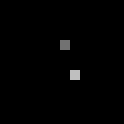

In [20]:
input_size = torch.Size((1, 124, 124))
img1_t = torch.zeros(input_size)
img1_t[:, 40:50, 60:70] = 0.45
img1_t[:, 70:80, 70:80] = 0.75
img1 = T.functional.to_pil_image(img1_t)
print(input_size)
display(img1)

Résultat du modèle

In [21]:
y1_t, pool_indices = aCnnModel(img1_t)
print(y1_t.size())
img_y1 = T.functional.to_pil_image(y1_t)
display(img_y1)

torch.Size([1, 25, 25])


Déconvolution en préservant toutes les activations

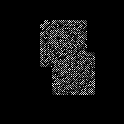

In [22]:
x_deconv = deconvolution(y1_t.detach(), aCnnModel, pool_indices)
img_deconv = T.functional.to_pil_image(x_deconv)
display(img_deconv)

In [23]:
max, max_indices = get_all_max_indices(y1_t.detach())
print(max)
print(max_indices)

282.0
tensor([[ 0, 15, 15],
        [ 0, 15, 16],
        [ 0, 16, 15],
        [ 0, 16, 16]])


Nettoyage de la carte des caractéristiques en préservant la première occurrence utile pour l'unpooling, de la valeur maximum.

In [32]:
y1t_cleaned = cleaning(y1_t.detach(), pool_indices=pool_indices[-1], keep_only_last_occurrence=False)
print(y1t_cleaned)

tensor([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
            0.,   0

Affichage de l'image correspondante

In [33]:
img_y1t_cleaned = T.functional.to_pil_image(y1t_cleaned)
display(img_y1t_cleaned)

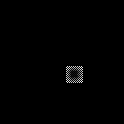

In [34]:
x_deconv = deconvolution(y1t_cleaned, aCnnModel, pool_indices)
img_deconv = T.functional.to_pil_image(x_deconv)
display(img_deconv)

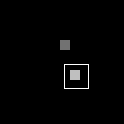

In [35]:
display(img1)

Calcul du champ réceptif

In [37]:
# (batch=1, channel=1, heigh, width)
input_size_for_summary = torch.Size([1, 1, input_size[-2], input_size[-1]])
output_sizes = get_output_sizes(aCnnModel.features, input_size=input_size_for_summary)
output_sizes

[(59, 59), (59, 59), (58, 58), (26, 26), (26, 26), (25, 25)]

In [38]:
pixel_space_size = (input_size[-2], input_size[-1])
idx_layer = -1 # last output
pos = max_indices[-1][-2:]
receptive_field = get_receptive_field_in_pixel_space(
    pos=pos,
    idx_layer=idx_layer,
    cnn_modules=aCnnModel.features,
    output_sizes=output_sizes,
    pixel_space_size=pixel_space_size
)
print(receptive_field)
((top, left), (bottom, right)) = receptive_field

((tensor(64), tensor(64)), (tensor(88), tensor(88)))


Visualisation du champ réceptif dans l'image de déconvolution et dans l'image initiale

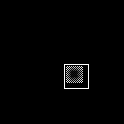

In [39]:
img_draw = ImageDraw.Draw(img_deconv)
img_draw.rectangle([(left, top), (right, bottom)], outline ="white")
display(img_deconv)

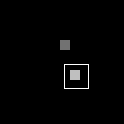

In [40]:
img_draw = ImageDraw.Draw(img1)
img_draw.rectangle([(left, top), (right, bottom)], outline ="white")
display(img1)